In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import argparse
from windspharm.standard import VectorWind
from windspharm.tools import prep_data, recover_data, order_latdim
from scipy.interpolate import griddata

# parser = argparse.ArgumentParser()
# parser.add_argument("--dir", type=str, required=True, help="directory")
# parser.add_argument("--ymd", type=str, required=True, help="forecast initial date")
# parser.add_argument("--ens", type=str, required=True, help="Ensemble member ID (e.g., e040)")
# args = parser.parse_args()


In [7]:
ds = xr.open_dataset("/glade/u/home/sressel/thesis-work/python/neuralGCM_analysis/2_8_thirty_year_DJF_climatology.nc")

In [8]:

# whenwhat = f"NgcmStocP2.8_{args.ymd}_{args.ens}"
# output_dir = f"/home/olympus/herakim/gdat_output/{args.dir}/"
# os.makedirs(output_dir, exist_ok=True)

# #----------------------------------------------------------------------------------
# # == open
# main_path = f"/home/olympus/herakim/{args.dir}/NgcmStocP2.8_z12_{args.ymd}_{args.ens}.nc"

# if not os.path.exists(main_path):
#     raise FileNotFoundError(f"{main_path} not found.")

# ds = xr.open_dataset(main_path)

# ds["time"] = pd.date_range(start=args.ymd+"T00:00:00", periods=101, freq="24H")

#----------------------------------------------------------------------------------
# == variable names
u = ds['u_component_of_wind']  # (time, level, lon, lat)
v = ds['v_component_of_wind']
q = ds['specific_humidity']
z = ds['geopotential']
t = ds['temperature']

# == level value check
levels = ds['level'].values
print("Available pressure levels (hPa):", levels)

# == level index
def find_level_idx(target_hpa):
    idx = np.argmin(np.abs(levels - target_hpa))
    print(f"Closest level to {target_hpa} hPa is {levels[idx]} hPa at index {idx}")
    return idx

idx_850 = find_level_idx(850)
idx_700 = find_level_idx(700)
idx_600 = find_level_idx(600)
idx_500 = find_level_idx(500)
idx_200 = find_level_idx(200)

# == extract variable and standardize the dimension names
def extract_and_standardize(da, idx):
    da = da.isel(level=idx).transpose("time", "latitude", "longitude")
    da = da.rename({'latitude': 'lat', 'longitude': 'lon'})
    return da

U850 = extract_and_standardize(u, idx_850)
V850 = extract_and_standardize(v, idx_850)
U200 = extract_and_standardize(u, idx_200)
V200 = extract_and_standardize(v, idx_200)

q850 = extract_and_standardize(q, idx_850)
q700 = extract_and_standardize(q, idx_700)
q600 = extract_and_standardize(q, idx_600)
q500 = extract_and_standardize(q, idx_500)

Z850 = extract_and_standardize(z, idx_850)
Z200 = extract_and_standardize(z, idx_200)
T200 = extract_and_standardize(t, idx_200)


# === velocity potential 
# S->N  to  N->S
if not (U200.lat[0] > U200.lat[-1]):
    U200 = U200.isel(lat=slice(None, None, -1))
    V200 = V200.isel(lat=slice(None, None, -1))

u200tmp, uinfo = prep_data(U200.values, 'tyx')
v200tmp, vinfo = prep_data(V200.values, 'tyx')

vw = VectorWind(u200tmp.astype('f4'), v200tmp.astype('f4'))
_, VP200 = vw.sfvp()
VP200 = recover_data(VP200, uinfo)

VP200 = xr.DataArray(
    VP200,
    coords=[U200.time, U200.lat, U200.lon],
    dims=['time', 'lat', 'lon'],
    name='vp'
)

# N->S to S->N
VP200 = VP200.isel(lat=slice(None, None, -1))
U200 = U200.isel(lat=slice(None, None, -1))
V200 = V200.isel(lat=slice(None, None, -1))

# == latitude order
if q600.lat.values[0] > q600.lat.values[-1]:
#    for var in [U850, V850, q700, q600, q500]:
#    for var in [U850, V850, q850]:
    for var in [Z850, Z200, T200]:
        var.sortby('lat', ascending=True)



Available pressure levels (hPa): [   1.    2.    3.    5.    7.   10.   20.   30.   50.   70.  100.  125.
  150.  175.  200.  225.  250.  300.  350.  400.  450.  500.  550.  600.
  650.  700.  750.  775.  800.  825.  850.  875.  900.  925.  950.  975.
 1000.]
Closest level to 850 hPa is 850.0 hPa at index 30
Closest level to 700 hPa is 700.0 hPa at index 25
Closest level to 600 hPa is 600.0 hPa at index 23
Closest level to 500 hPa is 500.0 hPa at index 21
Closest level to 200 hPa is 200.0 hPa at index 14


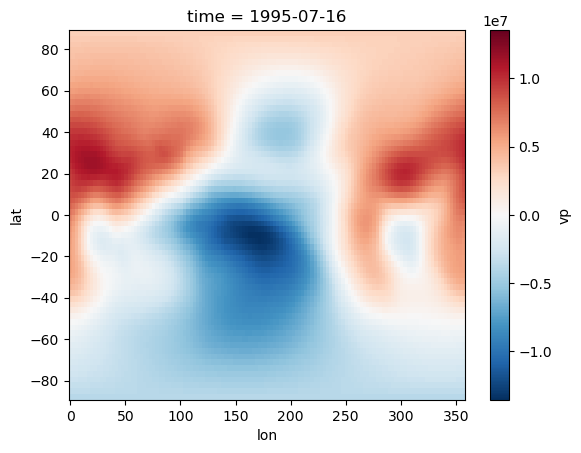

In [11]:
VP200.isel(time=0).plot(x='lon')

In [12]:
def lat_mean(var):
    return var.sel(lat=slice(-15, 15)).mean('lat')

u850_zm = lat_mean(U850)
u200_zm = lat_mean(U200)
vp200_zm = lat_mean(VP200)

In [ ]:
# === GDAT(float32)
def save_gdat(arr, name):
    arr.astype('float32').tofile(f"{output_dir}/{name}_{whenwhat}.gdat")
print(f"{output_dir}")

#save_gdat(U200.values, "U200")
#save_gdat(V200.values, "V200")
#save_gdat(q700.values, "q700")
#save_gdat(q500.values, "q500")
#save_gdat(chi, "VP200")

#save_gdat(q600.values, "q600")
#save_gdat(U850.values, "U850")
#save_gdat(V850.values, "V850")
#save_gdat(q850.values, "q850")
#save_gdat(q850.values*U850.values, "qu850")
#save_gdat(q850.values*V850.values, "qv850")

#save_gdat(Z200.values, "Z200")
#save_gdat(T200.values, "T200")
#save_gdat(Z850.values, "Z850")



## ALL variables are S->N by now ################################

# === interpolate into 144x73
new_lon = np.linspace(0, 357.5, 144)
new_lat = np.linspace(-90, 90, 73)

def interp_to_regular_xr(da, new_lat, new_lon):
    return da.interp(lat=new_lat, lon=new_lon, method='linear')

U850_interp = interp_to_regular_xr(xr.DataArray(U850.data, dims=U850.dims, coords=U850.coords, name=U850.name), new_lat, new_lon)
U200_interp = interp_to_regular_xr(xr.DataArray(U200.data, dims=U200.dims, coords=U200.coords, name=U200.name), new_lat, new_lon)
VP200_interp = interp_to_regular_xr(xr.DataArray(VP200.data, dims=VP200.dims, coords=VP200.coords, name=VP200.name), new_lat, new_lon)

# === lat mean  (15S~15N)
def lat_mean(var):
    return var.sel(lat=slice(-15, 15)).mean('lat')

u850_zm = lat_mean(U850_interp)
u200_zm = lat_mean(U200_interp)
vp200_zm = lat_mean(VP200_interp)

## Looks fine until here #########################################

# === load ERA5 anomaly + climatology
era5 = xr.open_dataset(f"/home/olympus/herakim/ERA5/era5_values_for_VPM_{args.ymd}.nc")
era5['valid_time'] = xr.decode_cf(era5).valid_time

forecast_start_date = np.datetime64(args.ymd)  # 2006-12-11
forecast_valid_time = forecast_start_date + np.arange(u200_zm.shape[0]) * np.timedelta64(1, 'D')

u850_zm = xr.DataArray( u850_zm.data, coords={"valid_time": forecast_valid_time, "lon": u850_zm.lon}, dims=["valid_time", "lon"], name="u")
u200_zm = xr.DataArray( u200_zm.data, coords={"valid_time": forecast_valid_time, "lon": u200_zm.lon}, dims=["valid_time", "lon"], name="u")
vp200_zm = xr.DataArray( vp200_zm.data, coords={"valid_time": forecast_valid_time, "lon": vp200_zm.lon}, dims=["valid_time", "lon"], name="u")

common_times = np.intersect1d(forecast_valid_time, era5.valid_time.values)
fc_anom_u200 = u200_zm.sel(valid_time=common_times) - era5['clim_u200_zm'].sel(valid_time=common_times).values
fc_anom_u850 = u850_zm.sel(valid_time=common_times) - era5['clim_u850_zm'].sel(valid_time=common_times).values
fc_anom_vp200 = vp200_zm.sel(valid_time=common_times) - era5['clim_vp200_zm'].sel(valid_time=common_times).values
#print(fc_anom_vp200)

era5_u200_hist = era5['u200_zm'].sel(valid_time=slice(common_times[0] - np.timedelta64(120, 'D'), common_times[0] - np.timedelta64(1, 'D')))
era5_u850_hist = era5['u850_zm'].sel(valid_time=era5_u200_hist.valid_time)
era5_vp200_hist = era5['vp200_zm'].sel(valid_time=era5_u200_hist.valid_time)

merged_u200 = np.concatenate([era5_u200_hist.values, fc_anom_u200.values], axis=0)
merged_u850 = np.concatenate([era5_u850_hist.values, fc_anom_u850.values], axis=0)
merged_vp200 = np.concatenate([era5_vp200_hist.values, fc_anom_vp200.values], axis=0)

# === subtract previous 120 days
def subtract_120day_sliding_mean(merged_array):
    out = []
    for i in range(120, merged_array.shape[0]):
        past_mean = np.nanmean(merged_array[i-120:i], axis=0)
        anom = merged_array[i] - past_mean
        out.append(anom)
    return np.stack(out)

final_anom_u200 = subtract_120day_sliding_mean(merged_u200)
final_anom_u850 = subtract_120day_sliding_mean(merged_u850)
final_anom_vp200 = subtract_120day_sliding_mean(merged_vp200)
#print(final_anom_u200)

# == normalize
#u200_std = 5.694395
#u850_std = 2.003139
#vp200_std = 5055818.

#u200norm = final_anom_u200 / u200_std
#u850norm = final_anom_u850 / u850_std
#vp200norm = final_anom_vp200 / vp200_std

#EOFinput = np.concatenate([u200norm, u850norm, vp200norm], axis=1)
# == save
EOFinput = np.concatenate([final_anom_u200, final_anom_u850, final_anom_vp200], axis=1)
EOFinput.astype('f4').tofile(f"{output_dir}/EOFinput_{whenwhat}.gdat")